In [1]:
# Step 1: Setup environment

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)
print("CUDA available:", torch.cuda.is_available())

Using device: cuda
CUDA available: True


In [2]:
# Step 2: Load MNIST dataset

# MNIST images are grayscale 28x28 images.
# ToTensor() converts images to PyTorch tensors and scales pixel values to [0, 1].
transform = transforms.Compose([
    transforms.ToTensor()
])

# Download MNIST training and test datasets
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    transform=transform,
    download=True
)

# Create DataLoaders
batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))
print("Image shape:", train_dataset[0][0].shape)
print("First label:", train_dataset[0][1])

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 486kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.54MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.49MB/s]

Training samples: 60000
Testing samples: 10000
Image shape: torch.Size([1, 28, 28])
First label: 5


In [3]:
# Step 3: Define CNN model

class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        # Input image shape: 1 x 28 x 28
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        # After two pooling layers:
        # 28x28 -> 14x14 -> 7x7
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # First convolution block
        x = self.pool(F.relu(self.conv1(x)))   # 1x28x28 -> 32x14x14

        # Second convolution block
        x = self.pool(F.relu(self.conv2(x)))   # 32x14x14 -> 64x7x7

        # Flatten image features
        x = x.view(x.size(0), -1)

        # Fully connected layers
        x = F.relu(self.fc1(x))
        x = self.fc2(x)                        # 10 output classes: 0 to 9

        return x


# Create model and move it to GPU
model = CNNModel().to(device)

print(model)

CNNModel(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [4]:
# Step 4: Train CNN model

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 3

def train_model(model, train_loader, criterion, optimizer, device, num_epochs):
    model.train()

    for epoch in range(num_epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            # Clear old gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass
            loss.backward()
            optimizer.step()

            # Track loss and accuracy
            running_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_accuracy = 100 * correct / total
        avg_loss = running_loss / len(train_loader)

        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%")

train_model(model, train_loader, criterion, optimizer, device, num_epochs)

Epoch [1/3], Loss: 0.2548, Train Accuracy: 92.43%
Epoch [2/3], Loss: 0.0614, Train Accuracy: 98.11%
Epoch [3/3], Loss: 0.0419, Train Accuracy: 98.75%


In [5]:
# Step 5: Test clean accuracy before attack

def test_clean_accuracy(model, test_loader, device):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy


clean_accuracy = test_clean_accuracy(model, test_loader, device)

print(f"Clean Test Accuracy before attack: {clean_accuracy:.2f}%")

Clean Test Accuracy before attack: 98.85%


In [6]:
# Step 6: FGSM Attack

def fgsm_attack(images, epsilon, data_grad):
    # Get the sign of the gradients
    sign_data_grad = data_grad.sign()

    # Create the perturbed image
    perturbed_images = images + epsilon * sign_data_grad

    # Keep pixel values between 0 and 1
    perturbed_images = torch.clamp(perturbed_images, 0, 1)

    return perturbed_images


def test_fgsm_attack(model, test_loader, device, epsilon):
    model.eval()

    total = 0
    correct_after_attack = 0

    clean_correct_total = 0
    attack_success_total = 0

    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        # We need gradient with respect to input image
        images.requires_grad = True

        # Forward pass on clean images
        outputs = model(images)
        _, clean_pred = torch.max(outputs.data, 1)

        # Only count images that were correctly classified before attack
        clean_correct_mask = clean_pred.eq(labels)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Clear gradients
        model.zero_grad()

        # Backward pass to get gradient of input image
        loss.backward()

        # Collect image gradient
        data_grad = images.grad.data

        # Generate adversarial images
        perturbed_images = fgsm_attack(images, epsilon, data_grad)

        # Test model on adversarial images
        adv_outputs = model(perturbed_images)
        _, adv_pred = torch.max(adv_outputs.data, 1)

        # Accuracy after attack
        total += labels.size(0)
        correct_after_attack += (adv_pred == labels).sum().item()

        # Attack Success Rate:
        # among originally correct samples, how many become wrong after attack
        clean_correct_total += clean_correct_mask.sum().item()
        attack_success_total += ((adv_pred != labels) & clean_correct_mask).sum().item()

    accuracy_after_attack = 100 * correct_after_attack / total
    attack_success_rate = 100 * attack_success_total / clean_correct_total

    return accuracy_after_attack, attack_success_rate


epsilon = 0.25

fgsm_accuracy, fgsm_asr = test_fgsm_attack(model, test_loader, device, epsilon)

print(f"FGSM epsilon: {epsilon}")
print(f"Clean Test Accuracy before attack: {clean_accuracy:.2f}%")
print(f"Test Accuracy after FGSM attack: {fgsm_accuracy:.2f}%")
print(f"FGSM Attack Success Rate (ASR): {fgsm_asr:.2f}%")

FGSM epsilon: 0.25
Clean Test Accuracy before attack: 98.85%
Test Accuracy after FGSM attack: 20.07%
FGSM Attack Success Rate (ASR): 79.70%


In [7]:
# Step 7: PGD / I-FGSM Attack

def pgd_attack(model, images, labels, epsilon, alpha, num_iter):
    # Save original clean images
    original_images = images.clone().detach()

    # Start from clean images
    perturbed_images = images.clone().detach()

    for i in range(num_iter):
        perturbed_images.requires_grad = True

        outputs = model(perturbed_images)
        loss = criterion(outputs, labels)

        model.zero_grad()
        loss.backward()

        # Get gradient sign
        data_grad = perturbed_images.grad.data

        # Take a small FGSM-like step
        perturbed_images = perturbed_images + alpha * data_grad.sign()

        # Project back to epsilon ball around original image
        perturbation = torch.clamp(
            perturbed_images - original_images,
            min=-epsilon,
            max=epsilon
        )

        perturbed_images = torch.clamp(
            original_images + perturbation,
            min=0,
            max=1
        ).detach()

    return perturbed_images


def test_pgd_attack(model, test_loader, device, epsilon, alpha, num_iter):
    model.eval()

    total = 0
    correct_after_attack = 0

    clean_correct_total = 0
    attack_success_total = 0

    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        # Clean prediction
        clean_outputs = model(images)
        _, clean_pred = torch.max(clean_outputs.data, 1)

        clean_correct_mask = clean_pred.eq(labels)

        # Generate adversarial images using PGD
        perturbed_images = pgd_attack(
            model,
            images,
            labels,
            epsilon,
            alpha,
            num_iter
        )

        # Test model on adversarial images
        adv_outputs = model(perturbed_images)
        _, adv_pred = torch.max(adv_outputs.data, 1)

        total += labels.size(0)
        correct_after_attack += (adv_pred == labels).sum().item()

        clean_correct_total += clean_correct_mask.sum().item()
        attack_success_total += ((adv_pred != labels) & clean_correct_mask).sum().item()

    accuracy_after_attack = 100 * correct_after_attack / total
    attack_success_rate = 100 * attack_success_total / clean_correct_total

    return accuracy_after_attack, attack_success_rate


epsilon = 0.25
alpha = 0.03
num_iter = 10

pgd_accuracy, pgd_asr = test_pgd_attack(
    model,
    test_loader,
    device,
    epsilon,
    alpha,
    num_iter
)

print(f"PGD epsilon: {epsilon}")
print(f"PGD alpha: {alpha}")
print(f"PGD iterations: {num_iter}")
print(f"Clean Test Accuracy before attack: {clean_accuracy:.2f}%")
print(f"Test Accuracy after PGD attack: {pgd_accuracy:.2f}%")
print(f"PGD Attack Success Rate (ASR): {pgd_asr:.2f}%")

PGD epsilon: 0.25
PGD alpha: 0.03
PGD iterations: 10
Clean Test Accuracy before attack: 98.85%
Test Accuracy after PGD attack: 0.27%
PGD Attack Success Rate (ASR): 99.73%


In [8]:
# Step 8: Momentum I-FGSM Attack

def momentum_ifgsm_attack(model, images, labels, epsilon, alpha, num_iter, decay_factor):
    # Save original clean images
    original_images = images.clone().detach()

    # Start from clean images
    perturbed_images = images.clone().detach()

    # Initialize momentum
    momentum = torch.zeros_like(images).to(device)

    for i in range(num_iter):
        perturbed_images.requires_grad = True

        outputs = model(perturbed_images)
        loss = criterion(outputs, labels)

        model.zero_grad()
        loss.backward()

        # Get gradient
        data_grad = perturbed_images.grad.data

        # Normalize gradient by mean absolute value
        grad_norm = data_grad / torch.mean(
            torch.abs(data_grad),
            dim=(1, 2, 3),
            keepdim=True
        )

        # Add momentum
        momentum = decay_factor * momentum + grad_norm

        # Update image using sign of momentum
        perturbed_images = perturbed_images + alpha * momentum.sign()

        # Project back to epsilon ball around original image
        perturbation = torch.clamp(
            perturbed_images - original_images,
            min=-epsilon,
            max=epsilon
        )

        # Keep image pixel values between 0 and 1
        perturbed_images = torch.clamp(
            original_images + perturbation,
            min=0,
            max=1
        ).detach()

    return perturbed_images


def test_momentum_ifgsm_attack(model, test_loader, device, epsilon, alpha, num_iter, decay_factor):
    model.eval()

    total = 0
    correct_after_attack = 0

    clean_correct_total = 0
    attack_success_total = 0

    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        # Clean prediction
        clean_outputs = model(images)
        _, clean_pred = torch.max(clean_outputs.data, 1)

        clean_correct_mask = clean_pred.eq(labels)

        # Generate adversarial images using Momentum I-FGSM
        perturbed_images = momentum_ifgsm_attack(
            model,
            images,
            labels,
            epsilon,
            alpha,
            num_iter,
            decay_factor
        )

        # Test model on adversarial images
        adv_outputs = model(perturbed_images)
        _, adv_pred = torch.max(adv_outputs.data, 1)

        total += labels.size(0)
        correct_after_attack += (adv_pred == labels).sum().item()

        clean_correct_total += clean_correct_mask.sum().item()
        attack_success_total += ((adv_pred != labels) & clean_correct_mask).sum().item()

    accuracy_after_attack = 100 * correct_after_attack / total
    attack_success_rate = 100 * attack_success_total / clean_correct_total

    return accuracy_after_attack, attack_success_rate


epsilon = 0.25
alpha = 0.03
num_iter = 10
decay_factor = 1.0

mifgsm_accuracy, mifgsm_asr = test_momentum_ifgsm_attack(
    model,
    test_loader,
    device,
    epsilon,
    alpha,
    num_iter,
    decay_factor
)

print(f"Momentum I-FGSM epsilon: {epsilon}")
print(f"Momentum I-FGSM alpha: {alpha}")
print(f"Momentum I-FGSM iterations: {num_iter}")
print(f"Momentum decay factor: {decay_factor}")
print(f"Clean Test Accuracy before attack: {clean_accuracy:.2f}%")
print(f"Test Accuracy after Momentum I-FGSM attack: {mifgsm_accuracy:.2f}%")
print(f"Momentum I-FGSM Attack Success Rate (ASR): {mifgsm_asr:.2f}%")

Momentum I-FGSM epsilon: 0.25
Momentum I-FGSM alpha: 0.03
Momentum I-FGSM iterations: 10
Momentum decay factor: 1.0
Clean Test Accuracy before attack: 98.85%
Test Accuracy after Momentum I-FGSM attack: 0.96%
Momentum I-FGSM Attack Success Rate (ASR): 99.03%


In [9]:
# Step 9: Create result summary table

results = {
    "Clean Accuracy Before Attack": clean_accuracy,
    "FGSM Accuracy After Attack": fgsm_accuracy,
    "FGSM ASR": fgsm_asr,
    "PGD Accuracy After Attack": pgd_accuracy,
    "PGD ASR": pgd_asr,
    "Momentum I-FGSM Accuracy After Attack": mifgsm_accuracy,
    "Momentum I-FGSM ASR": mifgsm_asr
}

print("MNIST Adversarial Attack Results")
print("=" * 40)
print(f"Clean Accuracy Before Attack: {clean_accuracy:.2f}%")
print()
print(f"FGSM Accuracy After Attack: {fgsm_accuracy:.2f}%")
print(f"FGSM Attack Success Rate: {fgsm_asr:.2f}%")
print()
print(f"PGD Accuracy After Attack: {pgd_accuracy:.2f}%")
print(f"PGD Attack Success Rate: {pgd_asr:.2f}%")
print()
print(f"Momentum I-FGSM Accuracy After Attack: {mifgsm_accuracy:.2f}%")
print(f"Momentum I-FGSM Attack Success Rate: {mifgsm_asr:.2f}%")

MNIST Adversarial Attack Results
Clean Accuracy Before Attack: 98.85%

FGSM Accuracy After Attack: 20.07%
FGSM Attack Success Rate: 79.70%

PGD Accuracy After Attack: 0.27%
PGD Attack Success Rate: 99.73%

Momentum I-FGSM Accuracy After Attack: 0.96%
Momentum I-FGSM Attack Success Rate: 99.03%


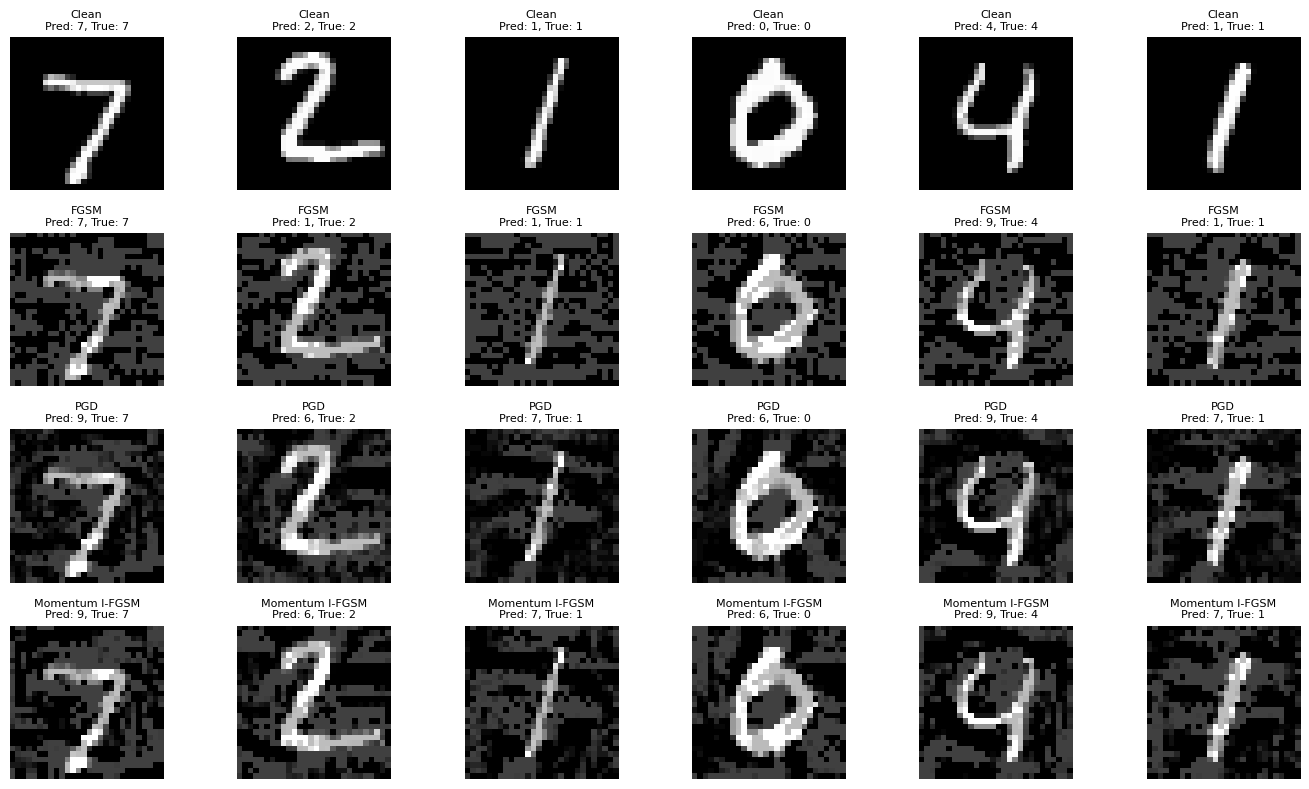

Saved file: attack_examples.png


In [10]:
# Step 10: Generate and save adversarial example images

def get_predictions(model, images):
    model.eval()
    with torch.no_grad():
        outputs = model(images)
        _, preds = torch.max(outputs.data, 1)
    return preds


def generate_attack_examples(
    model,
    test_loader,
    device,
    epsilon=0.25,
    alpha=0.03,
    num_iter=10,
    decay_factor=1.0,
    num_examples=6
):
    model.eval()

    # Get one batch from test data
    images, labels = next(iter(test_loader))
    images = images[:num_examples].to(device)
    labels = labels[:num_examples].to(device)

    # Clean predictions
    clean_preds = get_predictions(model, images)

    # FGSM attack
    fgsm_input = images.clone().detach()
    fgsm_input.requires_grad = True

    outputs = model(fgsm_input)
    loss = criterion(outputs, labels)

    model.zero_grad()
    loss.backward()

    data_grad = fgsm_input.grad.data
    fgsm_images = fgsm_attack(fgsm_input, epsilon, data_grad).detach()
    fgsm_preds = get_predictions(model, fgsm_images)

    # PGD attack
    pgd_images = pgd_attack(
        model,
        images.clone().detach(),
        labels,
        epsilon,
        alpha,
        num_iter
    ).detach()
    pgd_preds = get_predictions(model, pgd_images)

    # Momentum I-FGSM attack
    mifgsm_images = momentum_ifgsm_attack(
        model,
        images.clone().detach(),
        labels,
        epsilon,
        alpha,
        num_iter,
        decay_factor
    ).detach()
    mifgsm_preds = get_predictions(model, mifgsm_images)

    # Prepare rows for visualization
    image_rows = [
        ("Clean", images.detach(), clean_preds),
        ("FGSM", fgsm_images, fgsm_preds),
        ("PGD", pgd_images, pgd_preds),
        ("Momentum I-FGSM", mifgsm_images, mifgsm_preds)
    ]

    plt.figure(figsize=(14, 8))

    for row_idx, (attack_name, img_batch, pred_batch) in enumerate(image_rows):
        for col_idx in range(num_examples):
            plt.subplot(len(image_rows), num_examples, row_idx * num_examples + col_idx + 1)

            img = img_batch[col_idx].detach().cpu().squeeze().numpy()
            pred = pred_batch[col_idx].item()
            true = labels[col_idx].item()

            plt.imshow(img, cmap="gray")
            plt.title(f"{attack_name}\nPred: {pred}, True: {true}", fontsize=8)
            plt.axis("off")

    plt.tight_layout()
    plt.savefig("attack_examples.png", dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved file: attack_examples.png")


generate_attack_examples(
    model,
    test_loader,
    device,
    epsilon=0.25,
    alpha=0.03,
    num_iter=10,
    decay_factor=1.0,
    num_examples=6
)

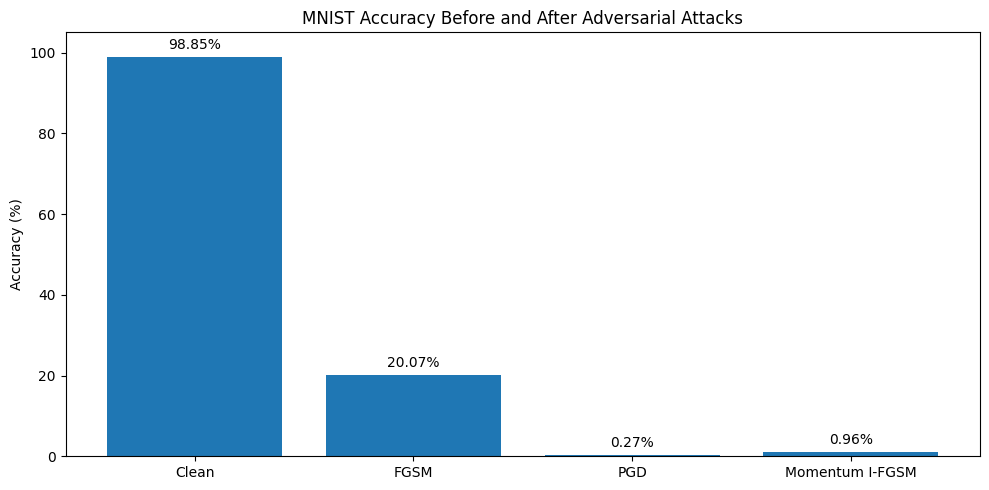

Saved file: attack_results.png
Saved file: summary.txt


In [11]:
# Step 11: Save result chart and summary file

# Create bar chart for attack results
attack_names = ["Clean", "FGSM", "PGD", "Momentum I-FGSM"]
accuracies = [clean_accuracy, fgsm_accuracy, pgd_accuracy, mifgsm_accuracy]
asr_values = [0, fgsm_asr, pgd_asr, mifgsm_asr]

plt.figure(figsize=(10, 5))
plt.bar(attack_names, accuracies)
plt.title("MNIST Accuracy Before and After Adversarial Attacks")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 105)

for i, value in enumerate(accuracies):
    plt.text(i, value + 2, f"{value:.2f}%", ha="center")

plt.tight_layout()
plt.savefig("attack_results.png", dpi=200, bbox_inches="tight")
plt.show()

# Save summary.txt
with open("summary.txt", "w") as f:
    f.write("MNIST Adversarial Attack Assignment\n")
    f.write("==================================\n\n")

    f.write("Dataset:\n")
    f.write("MNIST handwritten digit dataset\n")
    f.write("Training set: 60,000 images\n")
    f.write("Test set: 10,000 images\n")
    f.write("Image size: 1 x 28 x 28\n")
    f.write("Classes: digits 0 to 9\n\n")

    f.write("Model:\n")
    f.write("Convolutional Neural Network (CNN)\n\n")

    f.write("Metrics:\n")
    f.write("Recognition rate before attack = clean test accuracy\n")
    f.write("Attack Success Rate (ASR) = percentage of originally correct samples that became wrong after attack\n\n")

    f.write("Results:\n")
    f.write(f"Clean Test Accuracy Before Attack: {clean_accuracy:.2f}%\n\n")

    f.write(f"FGSM Accuracy After Attack: {fgsm_accuracy:.2f}%\n")
    f.write(f"FGSM Attack Success Rate (ASR): {fgsm_asr:.2f}%\n\n")

    f.write(f"PGD / I-FGSM Accuracy After Attack: {pgd_accuracy:.2f}%\n")
    f.write(f"PGD / I-FGSM Attack Success Rate (ASR): {pgd_asr:.2f}%\n\n")

    f.write(f"Momentum I-FGSM Accuracy After Attack: {mifgsm_accuracy:.2f}%\n")
    f.write(f"Momentum I-FGSM Attack Success Rate (ASR): {mifgsm_asr:.2f}%\n\n")

    f.write("Takeaway:\n")
    f.write("The CNN model has high clean accuracy on MNIST, but adversarial attacks can strongly reduce its performance.\n")
    f.write("PGD / I-FGSM is the strongest attack in this experiment.\n")

print("Saved file: attack_results.png")
print("Saved file: summary.txt")

In [12]:
# Step 12: Check generated files

!ls -lh

total 164K
-rw-r--r-- 1 root root  88K Aug 22 18:40 attack_examples.png
-rw-r--r-- 1 root root  62K Aug 22 18:42 attack_results.png
drwxr-xr-x 3 root root 4.0K Aug 22 18:14 data
drwxr-xr-x 1 root root 4.0K Aug 20 13:35 sample_data
-rw-r--r-- 1 root root  908 Aug 22 18:42 summary.txt


In [13]:
%%writefile mnist_attack_assignment.py
# MNIST Adversarial Attack Assignment
# Train CNN on MNIST and attack it using FGSM, PGD, and Momentum I-FGSM

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np


# -----------------------------
# 1. Setup
# -----------------------------
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# -----------------------------
# 2. Load MNIST Dataset
# -----------------------------
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    transform=transform,
    download=True
)

batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))


# -----------------------------
# 3. Define CNN Model
# -----------------------------
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x


model = CNNModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


# -----------------------------
# 4. Train Model
# -----------------------------
def train_model(model, train_loader, criterion, optimizer, device, num_epochs):
    model.train()

    for epoch in range(num_epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_accuracy = 100 * correct / total
        avg_loss = running_loss / len(train_loader)

        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%")


num_epochs = 3
train_model(model, train_loader, criterion, optimizer, device, num_epochs)


# -----------------------------
# 5. Clean Accuracy
# -----------------------------
def test_clean_accuracy(model, test_loader, device):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy


clean_accuracy = test_clean_accuracy(model, test_loader, device)
print(f"Clean Test Accuracy before attack: {clean_accuracy:.2f}%")


# -----------------------------
# 6. FGSM Attack
# -----------------------------
def fgsm_attack(images, epsilon, data_grad):
    sign_data_grad = data_grad.sign()
    perturbed_images = images + epsilon * sign_data_grad
    perturbed_images = torch.clamp(perturbed_images, 0, 1)
    return perturbed_images


def test_fgsm_attack(model, test_loader, device, epsilon):
    model.eval()

    total = 0
    correct_after_attack = 0

    clean_correct_total = 0
    attack_success_total = 0

    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        images.requires_grad = True

        outputs = model(images)
        _, clean_pred = torch.max(outputs.data, 1)

        clean_correct_mask = clean_pred.eq(labels)

        loss = criterion(outputs, labels)

        model.zero_grad()
        loss.backward()

        data_grad = images.grad.data

        perturbed_images = fgsm_attack(images, epsilon, data_grad)

        adv_outputs = model(perturbed_images)
        _, adv_pred = torch.max(adv_outputs.data, 1)

        total += labels.size(0)
        correct_after_attack += (adv_pred == labels).sum().item()

        clean_correct_total += clean_correct_mask.sum().item()
        attack_success_total += ((adv_pred != labels) & clean_correct_mask).sum().item()

    accuracy_after_attack = 100 * correct_after_attack / total
    attack_success_rate = 100 * attack_success_total / clean_correct_total

    return accuracy_after_attack, attack_success_rate


epsilon = 0.25

fgsm_accuracy, fgsm_asr = test_fgsm_attack(model, test_loader, device, epsilon)

print(f"FGSM epsilon: {epsilon}")
print(f"Test Accuracy after FGSM attack: {fgsm_accuracy:.2f}%")
print(f"FGSM Attack Success Rate (ASR): {fgsm_asr:.2f}%")


# -----------------------------
# 7. PGD / I-FGSM Attack
# -----------------------------
def pgd_attack(model, images, labels, epsilon, alpha, num_iter):
    original_images = images.clone().detach()
    perturbed_images = images.clone().detach()

    for i in range(num_iter):
        perturbed_images.requires_grad = True

        outputs = model(perturbed_images)
        loss = criterion(outputs, labels)

        model.zero_grad()
        loss.backward()

        data_grad = perturbed_images.grad.data

        perturbed_images = perturbed_images + alpha * data_grad.sign()

        perturbation = torch.clamp(
            perturbed_images - original_images,
            min=-epsilon,
            max=epsilon
        )

        perturbed_images = torch.clamp(
            original_images + perturbation,
            min=0,
            max=1
        ).detach()

    return perturbed_images


def test_pgd_attack(model, test_loader, device, epsilon, alpha, num_iter):
    model.eval()

    total = 0
    correct_after_attack = 0

    clean_correct_total = 0
    attack_success_total = 0

    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        clean_outputs = model(images)
        _, clean_pred = torch.max(clean_outputs.data, 1)

        clean_correct_mask = clean_pred.eq(labels)

        perturbed_images = pgd_attack(
            model,
            images,
            labels,
            epsilon,
            alpha,
            num_iter
        )

        adv_outputs = model(perturbed_images)
        _, adv_pred = torch.max(adv_outputs.data, 1)

        total += labels.size(0)
        correct_after_attack += (adv_pred == labels).sum().item()

        clean_correct_total += clean_correct_mask.sum().item()
        attack_success_total += ((adv_pred != labels) & clean_correct_mask).sum().item()

    accuracy_after_attack = 100 * correct_after_attack / total
    attack_success_rate = 100 * attack_success_total / clean_correct_total

    return accuracy_after_attack, attack_success_rate


epsilon = 0.25
alpha = 0.03
num_iter = 10

pgd_accuracy, pgd_asr = test_pgd_attack(
    model,
    test_loader,
    device,
    epsilon,
    alpha,
    num_iter
)

print(f"PGD epsilon: {epsilon}")
print(f"PGD alpha: {alpha}")
print(f"PGD iterations: {num_iter}")
print(f"Test Accuracy after PGD attack: {pgd_accuracy:.2f}%")
print(f"PGD Attack Success Rate (ASR): {pgd_asr:.2f}%")


# -----------------------------
# 8. Momentum I-FGSM Attack
# -----------------------------
def momentum_ifgsm_attack(model, images, labels, epsilon, alpha, num_iter, decay_factor):
    original_images = images.clone().detach()
    perturbed_images = images.clone().detach()

    momentum = torch.zeros_like(images).to(device)

    for i in range(num_iter):
        perturbed_images.requires_grad = True

        outputs = model(perturbed_images)
        loss = criterion(outputs, labels)

        model.zero_grad()
        loss.backward()

        data_grad = perturbed_images.grad.data

        grad_norm = data_grad / torch.mean(
            torch.abs(data_grad),
            dim=(1, 2, 3),
            keepdim=True
        )

        momentum = decay_factor * momentum + grad_norm

        perturbed_images = perturbed_images + alpha * momentum.sign()

        perturbation = torch.clamp(
            perturbed_images - original_images,
            min=-epsilon,
            max=epsilon
        )

        perturbed_images = torch.clamp(
            original_images + perturbation,
            min=0,
            max=1
        ).detach()

    return perturbed_images


def test_momentum_ifgsm_attack(model, test_loader, device, epsilon, alpha, num_iter, decay_factor):
    model.eval()

    total = 0
    correct_after_attack = 0

    clean_correct_total = 0
    attack_success_total = 0

    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        clean_outputs = model(images)
        _, clean_pred = torch.max(clean_outputs.data, 1)

        clean_correct_mask = clean_pred.eq(labels)

        perturbed_images = momentum_ifgsm_attack(
            model,
            images,
            labels,
            epsilon,
            alpha,
            num_iter,
            decay_factor
        )

        adv_outputs = model(perturbed_images)
        _, adv_pred = torch.max(adv_outputs.data, 1)

        total += labels.size(0)
        correct_after_attack += (adv_pred == labels).sum().item()

        clean_correct_total += clean_correct_mask.sum().item()
        attack_success_total += ((adv_pred != labels) & clean_correct_mask).sum().item()

    accuracy_after_attack = 100 * correct_after_attack / total
    attack_success_rate = 100 * attack_success_total / clean_correct_total

    return accuracy_after_attack, attack_success_rate


epsilon = 0.25
alpha = 0.03
num_iter = 10
decay_factor = 1.0

mifgsm_accuracy, mifgsm_asr = test_momentum_ifgsm_attack(
    model,
    test_loader,
    device,
    epsilon,
    alpha,
    num_iter,
    decay_factor
)

print(f"Momentum I-FGSM epsilon: {epsilon}")
print(f"Momentum I-FGSM alpha: {alpha}")
print(f"Momentum I-FGSM iterations: {num_iter}")
print(f"Momentum decay factor: {decay_factor}")
print(f"Test Accuracy after Momentum I-FGSM attack: {mifgsm_accuracy:.2f}%")
print(f"Momentum I-FGSM Attack Success Rate (ASR): {mifgsm_asr:.2f}%")


# -----------------------------
# 9. Save Attack Example Images
# -----------------------------
def get_predictions(model, images):
    model.eval()
    with torch.no_grad():
        outputs = model(images)
        _, preds = torch.max(outputs.data, 1)
    return preds


def generate_attack_examples(
    model,
    test_loader,
    device,
    epsilon=0.25,
    alpha=0.03,
    num_iter=10,
    decay_factor=1.0,
    num_examples=6
):
    model.eval()

    images, labels = next(iter(test_loader))
    images = images[:num_examples].to(device)
    labels = labels[:num_examples].to(device)

    clean_preds = get_predictions(model, images)

    fgsm_input = images.clone().detach()
    fgsm_input.requires_grad = True

    outputs = model(fgsm_input)
    loss = criterion(outputs, labels)

    model.zero_grad()
    loss.backward()

    data_grad = fgsm_input.grad.data
    fgsm_images = fgsm_attack(fgsm_input, epsilon, data_grad).detach()
    fgsm_preds = get_predictions(model, fgsm_images)

    pgd_images = pgd_attack(
        model,
        images.clone().detach(),
        labels,
        epsilon,
        alpha,
        num_iter
    ).detach()
    pgd_preds = get_predictions(model, pgd_images)

    mifgsm_images = momentum_ifgsm_attack(
        model,
        images.clone().detach(),
        labels,
        epsilon,
        alpha,
        num_iter,
        decay_factor
    ).detach()
    mifgsm_preds = get_predictions(model, mifgsm_images)

    image_rows = [
        ("Clean", images.detach(), clean_preds),
        ("FGSM", fgsm_images, fgsm_preds),
        ("PGD", pgd_images, pgd_preds),
        ("Momentum I-FGSM", mifgsm_images, mifgsm_preds)
    ]

    plt.figure(figsize=(14, 8))

    for row_idx, (attack_name, img_batch, pred_batch) in enumerate(image_rows):
        for col_idx in range(num_examples):
            plt.subplot(len(image_rows), num_examples, row_idx * num_examples + col_idx + 1)

            img = img_batch[col_idx].detach().cpu().squeeze().numpy()
            pred = pred_batch[col_idx].item()
            true = labels[col_idx].item()

            plt.imshow(img, cmap="gray")
            plt.title(f"{attack_name}\nPred: {pred}, True: {true}", fontsize=8)
            plt.axis("off")

    plt.tight_layout()
    plt.savefig("attack_examples.png", dpi=200, bbox_inches="tight")
    plt.close()


generate_attack_examples(
    model,
    test_loader,
    device,
    epsilon=0.25,
    alpha=0.03,
    num_iter=10,
    decay_factor=1.0,
    num_examples=6
)


# -----------------------------
# 10. Save Result Chart
# -----------------------------
attack_names = ["Clean", "FGSM", "PGD", "Momentum I-FGSM"]
accuracies = [clean_accuracy, fgsm_accuracy, pgd_accuracy, mifgsm_accuracy]

plt.figure(figsize=(10, 5))
plt.bar(attack_names, accuracies)
plt.title("MNIST Accuracy Before and After Adversarial Attacks")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 105)

for i, value in enumerate(accuracies):
    plt.text(i, value + 2, f"{value:.2f}%", ha="center")

plt.tight_layout()
plt.savefig("attack_results.png", dpi=200, bbox_inches="tight")
plt.close()


# -----------------------------
# 11. Save Summary
# -----------------------------
with open("summary.txt", "w") as f:
    f.write("MNIST Adversarial Attack Assignment\n")
    f.write("==================================\n\n")

    f.write("Dataset:\n")
    f.write("MNIST handwritten digit dataset\n")
    f.write("Training set: 60,000 images\n")
    f.write("Test set: 10,000 images\n")
    f.write("Image size: 1 x 28 x 28\n")
    f.write("Classes: digits 0 to 9\n\n")

    f.write("Model:\n")
    f.write("Convolutional Neural Network (CNN)\n\n")

    f.write("Metrics:\n")
    f.write("Recognition rate before attack = clean test accuracy\n")
    f.write("Attack Success Rate (ASR) = percentage of originally correct samples that became wrong after attack\n\n")

    f.write("Results:\n")
    f.write(f"Clean Test Accuracy Before Attack: {clean_accuracy:.2f}%\n\n")

    f.write(f"FGSM Accuracy After Attack: {fgsm_accuracy:.2f}%\n")
    f.write(f"FGSM Attack Success Rate (ASR): {fgsm_asr:.2f}%\n\n")

    f.write(f"PGD / I-FGSM Accuracy After Attack: {pgd_accuracy:.2f}%\n")
    f.write(f"PGD / I-FGSM Attack Success Rate (ASR): {pgd_asr:.2f}%\n\n")

    f.write(f"Momentum I-FGSM Accuracy After Attack: {mifgsm_accuracy:.2f}%\n")
    f.write(f"Momentum I-FGSM Attack Success Rate (ASR): {mifgsm_asr:.2f}%\n\n")

    f.write("Takeaway:\n")
    f.write("The CNN model has high clean accuracy on MNIST, but adversarial attacks can strongly reduce its performance.\n")
    f.write("PGD / I-FGSM is the strongest attack in this experiment.\n")


print("Created files:")
print("mnist_attack_assignment.py")
print("attack_examples.png")
print("attack_results.png")
print("summary.txt")

Writing mnist_attack_assignment.py


In [14]:
# Step 13: Final file check

!ls -lh

total 180K
-rw-r--r-- 1 root root  88K Aug 22 18:40 attack_examples.png
-rw-r--r-- 1 root root  62K Aug 22 18:42 attack_results.png
drwxr-xr-x 3 root root 4.0K Aug 22 18:14 data
-rw-r--r-- 1 root root  16K Aug 22 18:44 mnist_attack_assignment.py
drwxr-xr-x 1 root root 4.0K Aug 20 13:35 sample_data
-rw-r--r-- 1 root root  908 Aug 22 18:42 summary.txt
